<a href="https://colab.research.google.com/github/Jompy-GitHub/MTS-UncertainEnvironment/blob/main/analisis-resultados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introducción

Este Notebook es la continuación de la generación de los .csv y contiene un análisis de resultados de los experimentos. Se hace un análisis de los distintos algoritmos de búsqueda para cada experimento (por fuerza bruta, expanding square y lawnmower, y por heurísticas), y luego una comparación entre ambos.

El Experimento 1 mantiene la posición inicial del dron fija (punto rojo) y se calcula otra aleatoria para el objetivo dentro de la parcela de indicios (el campus de la universidad).

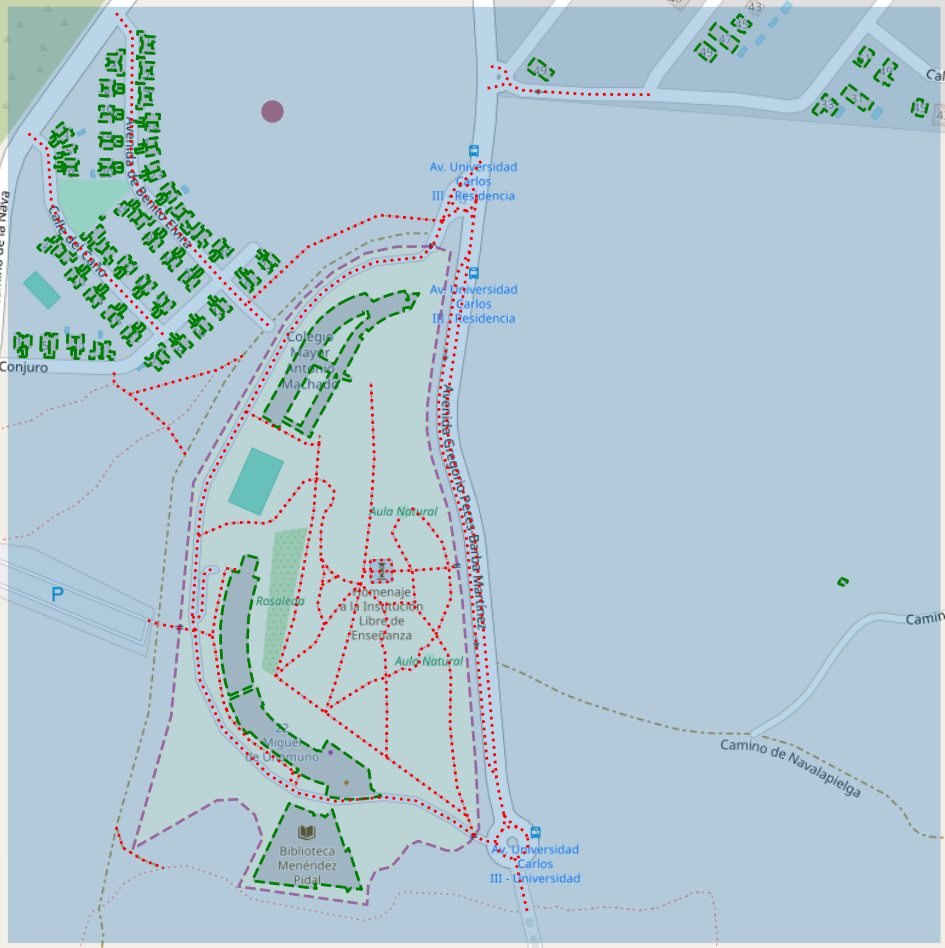

Para el Experimento 2 se hace al revés, la posición inicial del dron se calcula en los bordes del espacio de búsqueda (punto rojo a la izquierda), y el objetivo se fija en una posición dentro de la parcela de indicios.

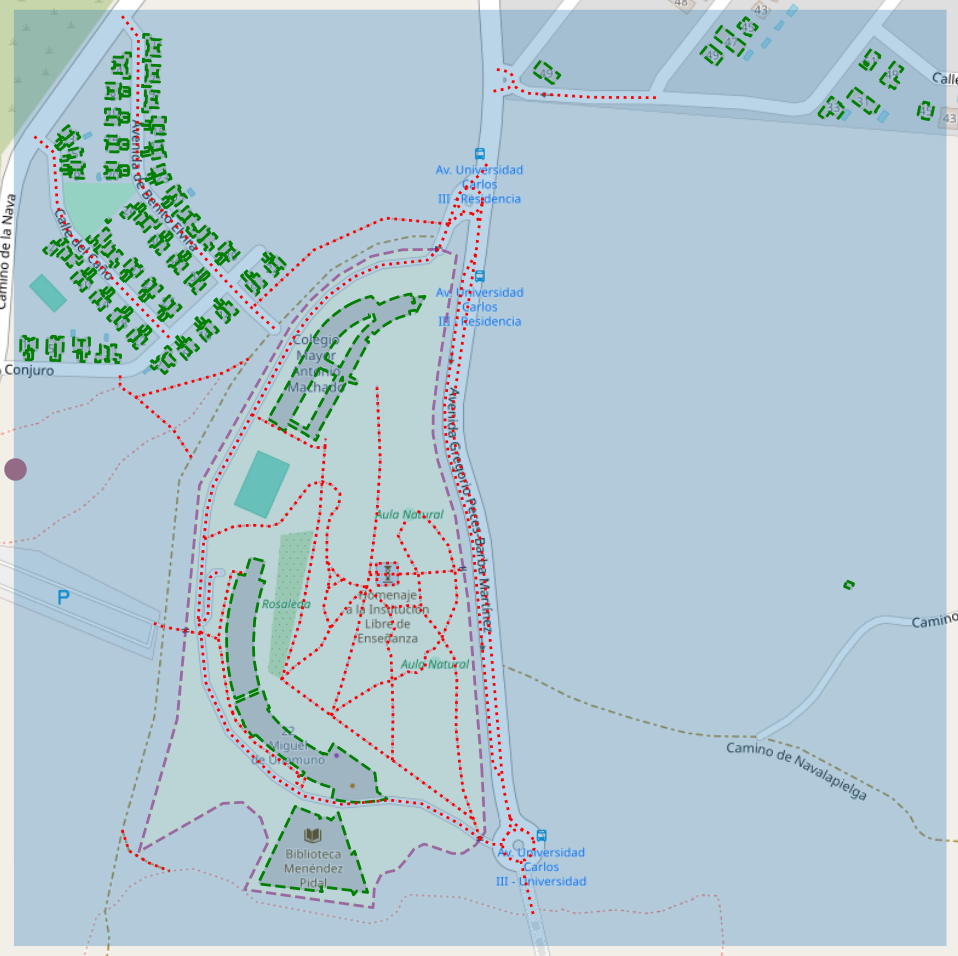

# Configuración el entorno

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

In [1]:
import os
import json
import subprocess

path = "drive/MyDrive/II-ADE/6º/TFG Informática/MTS/TFG_Alejandro"
#os.chdir(path)
print(os.listdir(os.getcwd()))

['uiux', 'Abstraccion_Espacio_Busqueda.drawio', 'resultados', 'bf-lawnmower-a.py', 'bf-expanding-a.py', 'ldfs-heur-a.py', 'ldfs-miope-a.py', 'Analisis_resultados_A.ipynb', 'Lanzar_pruebas_A.ipynb']


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde

In [3]:
def process_csv(file_path):
    # Coger el CSV y leer lo que nos interesa para las estadísticas
    # etiquetas, pasos y si se encontró el objetivo
    # Coger las filas: 3 (dist), 4(pasos/tiempo), 4(found),
    df = pd.read_csv(file_path, header=0, index_col=0 , nrows=3, skiprows=[1,2])

    # Sacar la estrategia del nombre del archivo
    strategy = os.path.basename(file_path).split(".")[0].split("-")[:-1]
    strategy = "-".join(strategy)

    # Sacar la información del df
    finder = df.loc["Found Target", "Target"]
    found = not np.isnan(finder)
    distance = float(df.loc["Distance", "Agent " + str(finder)]) if found else df.loc["Distance", "Agent 0"]
    steps = float(df.loc["Steps taken", "Agent 0"])
    steps_f = float(df.loc["Steps taken", "Agent " + str(finder)]) if found else None
    agents = len(df.columns) - 1

    result_df = pd.DataFrame(
        {
            "Strategy": strategy,
            "Number of Agents": agents,
            "Steps": steps,
            "Steps finder": steps_f,
            "Distance": distance,
            "Found": found,
        },
        index=(["values"]),
    )
    return result_df

In [4]:
def process_all(directory):
    # Toma todos los archivos csv de la carpeta y los "procesa" (juntar los datos en un df)
    all_data = []
    for filename in os.listdir(directory):
        if not filename.endswith(".csv"):
            continue
        file_path = os.path.join(directory, filename)
        df = process_csv(file_path)
        all_data.append(df)
    return pd.concat(all_data, ignore_index=True)

# Experimento 1

Dron fijo y objetivo aleatorio dentro de la universidad.

## Cargar los archivos

In [6]:
# Abrir la carpeta para el analisis (tarda ~1 min/1000 archivos)
print(os.getcwd())

# Probar os.chdir(ruta)
conf = "prueba/Experimento 1 dron (40,40)/"
testing_path = "./resultados/" + conf
#testing_path = "drive/MyDrive/II-ADE/6º/TFG Informática/MTS - Trajectories/resultados/" + conf


combined_data_exp1 = process_all(testing_path)

successful_df_exp1 = combined_data_exp1[combined_data_exp1["Found"]]
#print(os.getcwd())

g:\My Drive\II-ADE\6º\TFG Informática\MTS\TFG_Alejandro


In [7]:
print(combined_data_exp1)

       Strategy  Number of Agents   Steps Steps finder    Distance  Found
0     expanding                 1   596.0        596.0   1211.8823   True
1     expanding                 1  2503.0       2503.0   5025.8823   True
2     expanding                 1   468.0        468.0    955.8823   True
3     expanding                 1   886.0        886.0   1791.8823   True
4     expanding                 1   580.0        580.0   1179.8823   True
...         ...               ...     ...          ...         ...    ...
3995  ldfs-heur                 1  5000.0         None  10933.9022  False
3996  ldfs-heur                 1    57.0         57.0    138.8528   True
3997  ldfs-heur                 1  5000.0         None  10939.0737  False
3998  ldfs-heur                 1   102.0        102.0    241.2792   True
3999  ldfs-heur                 1   328.0        328.0    744.6417   True

[4000 rows x 6 columns]


In [8]:
# Se convierte la columna Distance a numérica para poder hacer estadísticas
combined_data_exp1["Distance"] = pd.to_numeric(combined_data_exp1["Distance"])


In [9]:
combined_data_exp1.dtypes

Strategy             object
Number of Agents      int64
Steps               float64
Steps finder         object
Distance            float64
Found                  bool
dtype: object

In [11]:
strategies = combined_data_exp1['Strategy'].unique()[::-1]
print(strategies)
colors_total = ['#5B75A4', '#A45B99', '#A48A5B', '#5BA466']
print(colors_total)

['expanding' 'lawnmower' 'ldfs-myop' 'ldfs-heur']
['#5B75A4', '#A45B99', '#A48A5B', '#5BA466']


### Estadísticas descriptivas

Para cada estrategia, se evalúan las estadísticas que ayudan a comprender su desempeño, como la media, desviación típica, mediana y rango.

In [12]:
# Estadísticas para Steps
combined_data_exp1.groupby("Strategy")["Steps"].describe()

#La mediana es el 50% y el rango es max - min

,count,mean,std,min,25%,50%,75%,max
Strategy,,,,,,,,
expanding,1000.0,1047.175,710.288099,8.0,474.5,904.0,1487.00,3091.0
lawnmower,1000.0,2353.710,645.035064,800.0,1849.0,2377.0,2880.25,3564.0
ldfs-heur,1000.0,1703.660,1965.079789,13.0,199.0,400.5,3525.00,5000.0
ldfs-myop,1000.0,648.015,597.362995,11.0,182.0,439.0,977.00,4596.0


In [13]:
# La distancia que más se repite por algoritmo (moda)
combined_data_exp1.groupby("Strategy")["Steps"].agg(lambda x: x.mode().iloc[0])

Strategy
expanding       9.0
lawnmower    1944.0
ldfs-heur    5000.0
ldfs-myop     168.0
Name: Steps, dtype: float64

In [14]:
# Estadísticas para Distance
combined_data_exp1.groupby("Strategy")["Distance"].describe()

,count,mean,std,min,25%,50%,75%,max
Strategy,,,,,,,,
expanding,1000.0,2113.917496,1421.036678,21.7990,968.8823,1827.88230,2993.882300,6201.8823
lawnmower,1000.0,4666.159300,1275.059404,1594.0833,3668.0833,4712.08330,5706.583300,7058.0833
ldfs-heur,1000.0,3709.528911,4238.283485,27.6569,456.7117,914.49450,7676.077825,11451.1326
ldfs-myop,1000.0,1579.902561,1405.052044,28.6274,474.7996,1037.44485,2393.985200,10786.7978


En primer lugar, es importante saber cuántos y qué porcentaje representan las misiones que encuentran el objetivo (éxito) y las que no.

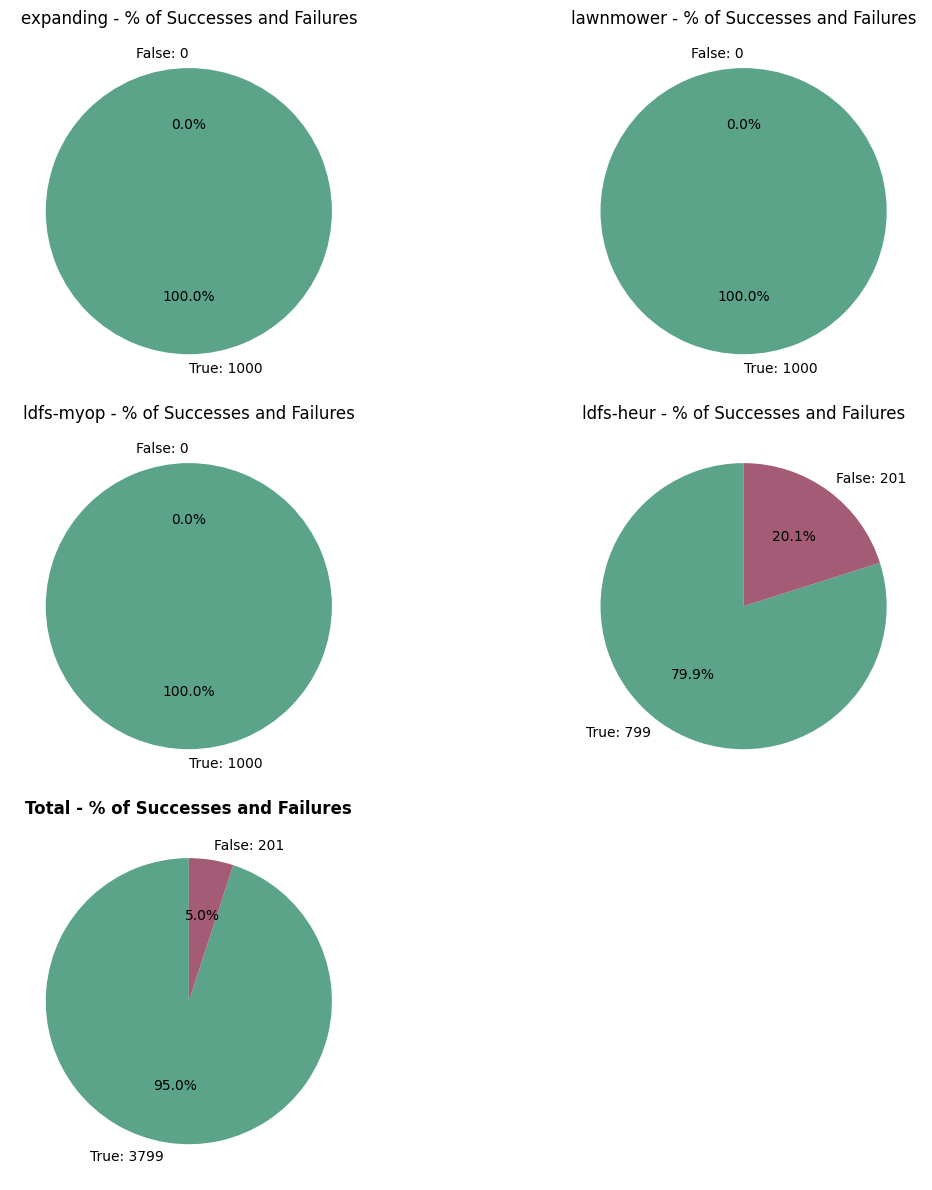

In [15]:
colors = ['#5BA48A', '#A45B75']
colors_total = ['#A45B75', '#5BA48A', '#655BA4', '#75A45B', '#5B75A4']

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, strategy in enumerate(strategies):
    ax = axes[i]
    
    strategy_data = combined_data_exp1[combined_data_exp1["Strategy"] == strategy]
    
    found_counts = strategy_data["Found"].value_counts()
    values = [found_counts.get(True, 0), found_counts.get(False, 0)]
    labels = [f'True: {values[0]}', f'False: {values[1]}']
    

    ax.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
    ax.set_title(f'{strategy} - % of Successes and Failures')


ax_total = axes[len(strategies)]
found_counts_total = combined_data_exp1["Found"].value_counts()
values_total = [found_counts_total.get(True, 0), found_counts_total.get(False, 0)]
labels_total = [f'True: {values_total[0]}', f'False: {values_total[1]}']

ax_total.pie(values_total, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors)
ax_total.set_title('Total - % of Successes and Failures', fontweight='bold')

# Sobra el 6 gráfico de la malla
for j in range(len(strategies) + 1, len(axes)):  
    fig.delaxes(axes[j])  

plt.tight_layout()
plt.show()

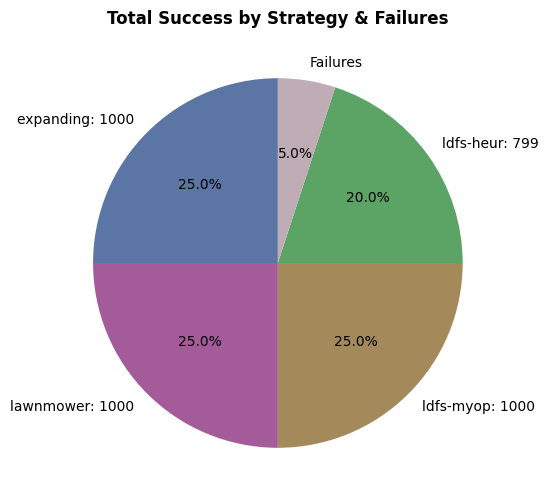

In [16]:
#colors_total = ['#A45B75', '#5BA48A', '#655BA4', '#75A45B', '#5B75A4']  
colors_total = ['#5B75A4', '#A45B99', '#A48A5B', '#5BA466', '#BFACB5']
strategy_colors = colors_total[:-1]  
failure_color = colors_total[-1]

success_counts = combined_data_exp1[combined_data_exp1["Found"] == True]["Strategy"].value_counts()

failure_count = (combined_data_exp1["Found"] == False).sum()

labels = [f"{strategy}: {success_counts.get(strategy, 0)}" for strategy in strategies] + ["Failures"]
sizes = [success_counts.get(strategy, 0) for strategy in strategies] + [failure_count]
colors = strategy_colors + [failure_color]

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
ax.set_title("Total Success by Strategy & Failures", fontweight="bold")

plt.show()

Para ver cuánto tiempo tarda cada algoritmo tarda en encontrar el objetivo, se calcula el número de Steps y Distance promedio por cada uno.

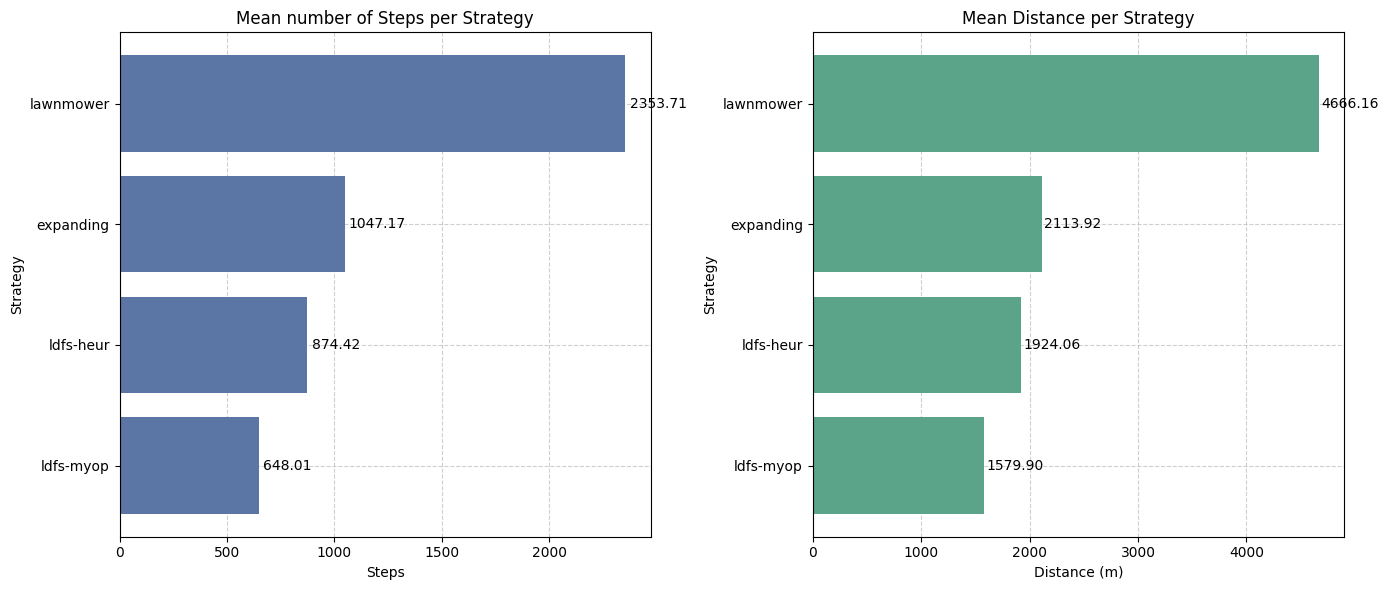

In [17]:
# Se agrupa cada estrategia y se calcula el promedio de los steps y la distancia
mean_steps = successful_df_exp1.groupby('Strategy')['Steps'].mean().sort_values()
mean_distance = successful_df_exp1.groupby('Strategy')['Distance'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de barras horizontales para Steps
axes[0].set_axisbelow(True)
axes[0].grid(True, linestyle="--", alpha=0.6)
bars_steps = axes[0].barh(mean_steps.index, mean_steps.values, color='#5B75A4')
axes[0].set_title('Mean number of Steps per Strategy')
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Steps
for bar in bars_steps:
    axes[0].text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2, 
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

# Gráfico de barras horizontales para Distance
axes[1].set_axisbelow(True)
axes[1].grid(True, linestyle="--", alpha=0.6)
bars_distance = axes[1].barh(mean_distance.index, mean_distance.values, color='#5BA48A')
axes[1].set_title('Mean Distance per Strategy')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Distance
for bar in bars_distance:
    axes[1].text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2, 
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

plt.tight_layout()
plt.show()


Otra manera de verlo es el número de Steps con respecto al número de ejecuciones.

In [18]:
execution_data = []

for strategy, group in combined_data_exp1.groupby("Strategy"):
    num_executions = len(group)  
    executions = list(range(1, num_executions + 1)) 
    

    execution_data.extend(zip(executions, [strategy] * num_executions))


execution_df = pd.DataFrame(execution_data, columns=["Execution", "Strategy"])

print(execution_df)

      Execution   Strategy
0             1  expanding
1             2  expanding
2             3  expanding
3             4  expanding
4             5  expanding
...         ...        ...
3995        996  ldfs-myop
3996        997  ldfs-myop
3997        998  ldfs-myop
3998        999  ldfs-myop
3999       1000  ldfs-myop

[4000 rows x 2 columns]


También se hace el plot de la distribución de los Steps que require a cada algoritmo llegar al objetivo. Todas las gráficas tienen la misma escala para que la comparación sea más representativa.

In [19]:
global_xmin = combined_data_exp1["Steps"].min()
global_xmax = combined_data_exp1["Steps"].max()
global_ymax = combined_data_exp1.groupby("Strategy")["Steps"].value_counts().max().max()


fig_hist = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[f'Distribution of Steps for {s}' for s in strategies],
    vertical_spacing=0.1,
    horizontal_spacing=0.1,
)

for idx, strategy in enumerate(strategies):
    row = idx // 2 + 1 
    col = idx % 2 + 1  

    strategy_data = combined_data_exp1[combined_data_exp1['Strategy'] == strategy]['Steps'].dropna()

    # Histograma
    fig_hist.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200, 
            marker=dict(color='#5BA48A'),  
            opacity=1 
        ),
        row=row,
        col=col
    )

    if len(strategy_data) > 1:  
        kde = gaussian_kde(strategy_data)
        x_vals = np.linspace(global_xmin, global_xmax, 500) 
        y_vals = kde(x_vals)  
        y_vals = y_vals * len(strategy_data) * (global_xmax - global_xmin) / 200  

        fig_hist.add_trace(
            go.Scatter(
                x=x_vals,
                y=y_vals,
                mode='lines',
                line=dict(color='#A45B75', width=1.5),
                name=f'KDE - {strategy}',
            ),
            row=row,
            col=col
        )

    fig_hist.update_xaxes(title_text="Number of Steps", row=row, col=col, range=[global_xmin, global_xmax])
    fig_hist.update_yaxes(title_text="Frequency", row=row, col=col, range=[0, global_ymax])

fig_hist.update_layout(
    showlegend=False,
    title_text="Steps Distribution by Strategy",
    height=1000,  
    width=1000,
    bargap=0.1,
)

fig_hist.show()

Histogramas de todas las estrategias superpuestos

In [20]:
colors_total = ['#5B75A4', '#A45B99', '#A48A5B', '#5BA466', '#BFACB5']

# Histograma combinado
fig_combined = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp1[combined_data_exp1['Strategy'] == strategy]['Steps'].dropna()

    # Histograma para cada estrategia
    fig_combined.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200, 
            opacity=0.8,  
            marker=dict(color=colors_total[idx % len(colors_total)]), 
        )
    )

fig_combined.update_layout(
    title_text="Combined Steps Distribution for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Frequency",
    barmode='overlay', 
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,  
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,  
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

fig_combined.show()


La CDF permite visualizar cómo se distribuyen los datos de los 'steps' a medida que se acumulan más valores:

In [21]:
colors_total = ['#5B75A4', '#A45B99', '#A48A5B', '#5BA466', '#BFACB5']
line_styles = ['solid', 'dash', 'dot', 'dashdot', 'longdash']

# Figura de Cumulative Distribution Function
fig_cumulative = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp1[combined_data_exp1['Strategy'] == strategy]['Steps'].dropna()

    # Calcular la distribución acumulada
    sorted_data = np.sort(strategy_data)
    y_vals = np.arange(1, len(sorted_data) + 1) / len(sorted_data)  # Normalización a 0-1
    color = colors_total[idx % len(colors_total)]  # Color
    line_style = line_styles[idx % len(line_styles)]  # Tipo de línea

    # Curva
    fig_cumulative.add_trace(
        go.Scatter(
            x=sorted_data,
            y=y_vals,
            mode='lines',
            name=strategy,
            line=dict(color=color, dash=line_style),
            opacity=0.8
        )
    )

fig_cumulative.update_layout(
    title_text="Cumulative Distribution of Steps for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Cumulative Frequency",
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray', 
        gridwidth=1, 
    ),
    plot_bgcolor='white',  
)

fig_cumulative.show()

Y, por último, también se añaden los boxplot, que ayudan a entender la distribución con más información (rango, percentiles, outliers, etc.).

In [22]:
# Crear un diccionario para mapear las estrategias a los colores
strategy_to_color = dict(zip(strategies, colors_total))

point_color = '#BFACB5'


fig_box = px.box(successful_df_exp1,
                 x='Strategy',
                 y='Steps',
                 title='Steps Distribution (Box Plot)',
                 labels={'Steps': 'Number of Steps'},
                 height=500,
                 category_orders={'Strategy': strategies},  
                 color='Strategy',
                 color_discrete_map=strategy_to_color
)

# Añadir los puntos de dispersión para todos los casos de prueba (incluyendo los fallidos)
for strategy in combined_data_exp1['Strategy'].unique():
    strategy_data = combined_data_exp1[combined_data_exp1['Strategy'] == strategy]
    

    fig_box.add_trace(
        go.Scatter(
            x=[strategy] * len(strategy_data),
            y=strategy_data['Steps'],
            mode='markers',
            marker=dict(
                color=point_color,
                opacity=0.2,
                size=5
            ),
            showlegend=False,
        )
    )

fig_box.update_layout(
    height=500,
    title='Steps Distribution (Box Plot with All Attempts)',
    yaxis_title='Number of Steps',
)

fig_box.show()

# Experimento 2

Dron aleatorio en los bordes del espacio de búsqueda y target fijo dentro de la parcela de indicios.

## Cargar los archivos

In [10]:
# Abrir la carpeta para el analisis (tarda ~1 min/1000 archivos)
print(os.getcwd())

# Probar os.chdir(ruta)
conf = "prueba/Experimento 2 obj (56,82)/"
testing_path = "./resultados/" + conf
#testing_path = "drive/MyDrive/II-ADE/6º/TFG Informática/MTS - Trajectories/resultados/" + conf


combined_data_exp2 = process_all(testing_path)

successful_df_exp2 = combined_data_exp2[combined_data_exp2["Found"]]
#print(os.getcwd())

g:\My Drive\II-ADE\6º\TFG Informática\MTS\TFG_Alejandro


In [ ]:
print(combined_data_exp2)

       Strategy  Number of Agents   Steps Steps finder   Distance  Found
0     ldfs-myop                 1  1069.0       1069.0  2486.2278   True
1     ldfs-myop                 1  2144.0       2144.0  4948.3136   True
2     ldfs-myop                 1  2936.0       2936.0  6592.3219   True
3     ldfs-myop                 1  1480.0       1480.0  3591.9864   True
4     ldfs-myop                 1   664.0        664.0  1603.7973   True
...         ...               ...     ...          ...        ...    ...
3995  expanding                 1   600.0        600.0  1227.3381   True
3996  expanding                 1   600.0        600.0  1233.1371   True
3997  expanding                 1   599.0        599.0  1225.3381   True
3998  expanding                 1   600.0        600.0  1207.4558   True
3999  expanding                 1   600.0        600.0  1214.0833   True

[4000 rows x 6 columns]


In [ ]:
combined_data_exp2[combined_data_exp2['Steps'] > 5000]


,Strategy,Number of Agents,Steps,Steps finder,Distance,Found


In [26]:
# Se convierte la columna Distance a numérica para poder hacer estadísticas
combined_data_exp2["Distance"] = pd.to_numeric(combined_data_exp2["Distance"])


In [27]:
combined_data_exp2.dtypes

Strategy             object
Number of Agents      int64
Steps               float64
Steps finder         object
Distance            float64
Found                  bool
dtype: object

In [28]:
strategies = combined_data_exp2['Strategy'].unique()[::-1]
print(strategies)
colors_total = ['#5B75A4', '#A45B99', '#A48A5B', '#5BA466']
print(colors_total)

['expanding' 'ldfs-heur' 'lawnmower' 'ldfs-myop']
['#5B75A4', '#A45B99', '#A48A5B', '#5BA466']


### Estadísticas descriptivas

Para cada estrategia, se evalúan las estadísticas que ayudan a comprender su desempeño, como la media, desviación típica, mediana y rango.

In [29]:
# Estadísticas para Steps
combined_data_exp2.groupby("Strategy")["Steps"].describe()

#La mediana es el 50% y el rango es max - min

,count,mean,std,min,25%,50%,75%,max
Strategy,,,,,,,,
expanding,1000.0,591.175,69.428890,28.0,599.00,600.0,600.00,601.0
lawnmower,1000.0,2637.906,1925.060022,85.0,124.00,2220.0,4954.00,4988.0
ldfs-heur,1000.0,1993.428,1927.626048,47.0,199.25,1249.5,3898.75,5000.0
ldfs-myop,1000.0,1930.018,1193.860797,110.0,1044.00,1472.0,2532.50,5000.0


In [30]:
# La distancia que más se repite por algoritmo (moda)
combined_data_exp2.groupby("Strategy")["Steps"].agg(lambda x: x.mode().iloc[0])

Strategy
expanding     600.0
lawnmower    4977.0
ldfs-heur    5000.0
ldfs-myop    5000.0
Name: Steps, dtype: float64

In [31]:
# Estadísticas para Distance
combined_data_exp2.groupby("Strategy")["Distance"].describe()

,count,mean,std,min,25%,50%,75%,max
Strategy,,,,,,,,
expanding,1000.0,1200.669009,138.693293,78.3675,1207.941100,1217.2254,1226.99490,1237.6224
lawnmower,1000.0,5234.213396,3779.916672,240.4163,318.416300,4388.8284,9792.82840,9860.8284
ldfs-heur,1000.0,4292.122948,4131.989424,116.3675,442.866075,2691.5466,8368.92870,10968.6271
ldfs-myop,1000.0,4446.222578,2529.628232,235.2203,2605.185825,3518.8077,5736.61315,11077.9307


En primer lugar, es importante saber cuántos y qué porcentaje representan las misiones que encuentran el objetivo (éxito) y las que no.

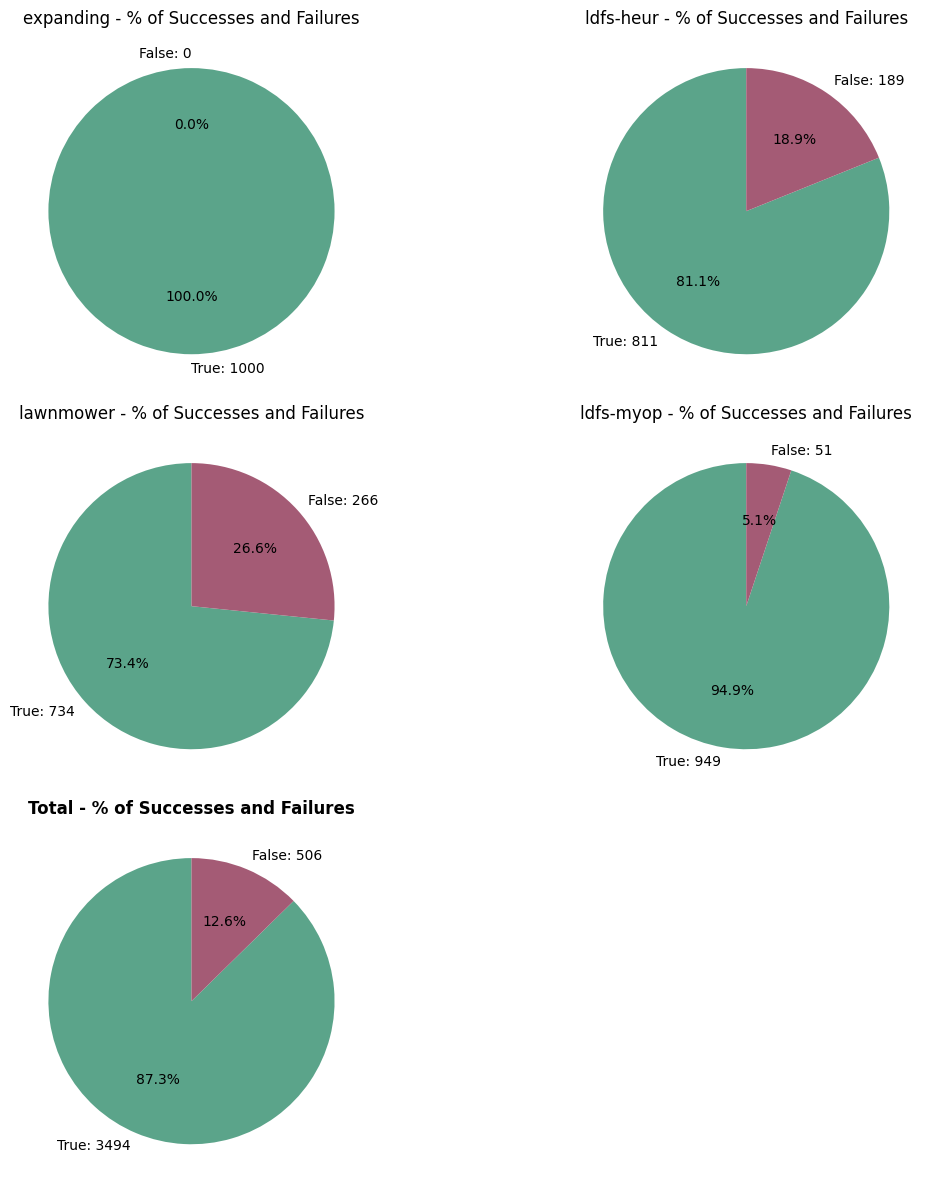

In [32]:
colors = ['#5BA48A', '#A45B75']
colors_total = ['#A45B75', '#5BA48A', '#655BA4', '#75A45B', '#5B75A4']

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, strategy in enumerate(strategies):
    ax = axes[i]
    
    strategy_data = combined_data_exp2[combined_data_exp2["Strategy"] == strategy]
    
    found_counts = strategy_data["Found"].value_counts()
    values = [found_counts.get(True, 0), found_counts.get(False, 0)]
    labels = [f'True: {values[0]}', f'False: {values[1]}']
    

    ax.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
    ax.set_title(f'{strategy} - % of Successes and Failures')


ax_total = axes[len(strategies)]
found_counts_total = combined_data_exp2["Found"].value_counts()
values_total = [found_counts_total.get(True, 0), found_counts_total.get(False, 0)]
labels_total = [f'True: {values_total[0]}', f'False: {values_total[1]}']

ax_total.pie(values_total, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors)
ax_total.set_title('Total - % of Successes and Failures', fontweight='bold')

# Sobra el 6 gráfico de la malla
for j in range(len(strategies) + 1, len(axes)):  
    fig.delaxes(axes[j])  

plt.tight_layout()
plt.show()

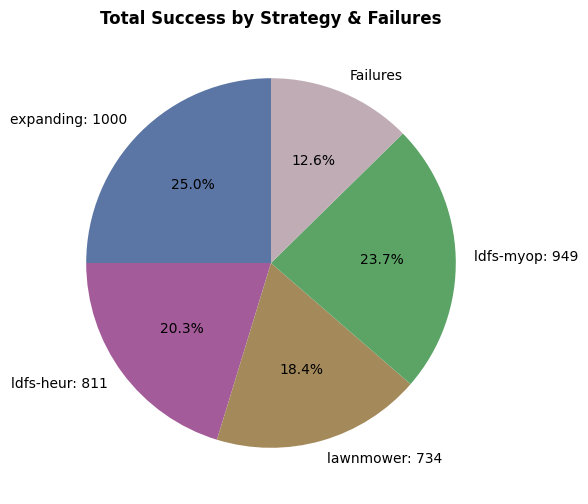

In [33]:
#colors_total = ['#A45B75', '#5BA48A', '#655BA4', '#75A45B', '#5B75A4']  
colors_total = ['#5B75A4', '#A45B99', '#A48A5B', '#5BA466', '#BFACB5']
strategy_colors = colors_total[:-1]  
failure_color = colors_total[-1]

success_counts = combined_data_exp2[combined_data_exp2["Found"] == True]["Strategy"].value_counts()

failure_count = (combined_data_exp2["Found"] == False).sum()

labels = [f"{strategy}: {success_counts.get(strategy, 0)}" for strategy in strategies] + ["Failures"]
sizes = [success_counts.get(strategy, 0) for strategy in strategies] + [failure_count]
colors = strategy_colors + [failure_color]

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
ax.set_title("Total Success by Strategy & Failures", fontweight="bold")

plt.show()

Para ver cuánto tiempo tarda cada algoritmo tarda en encontrar el objetivo, se calcula el número de Steps y Distance promedio por cada uno.

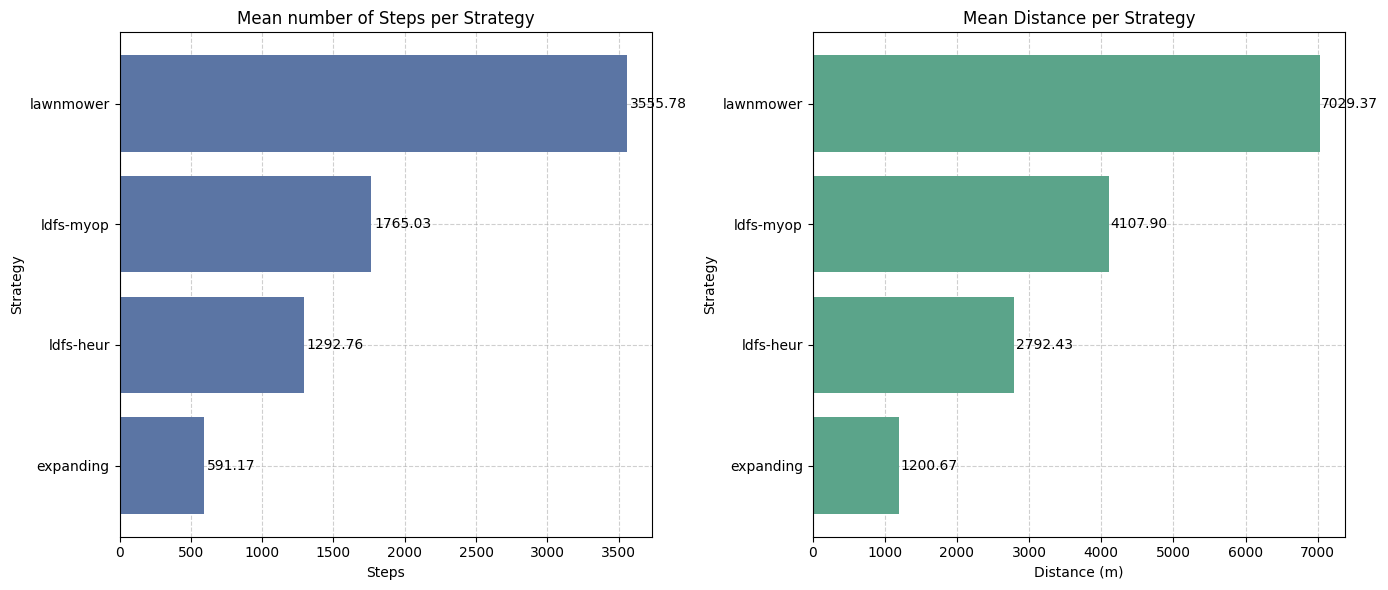

In [34]:
# Se agrupa cada estrategia y se calcula el promedio de los steps y la distancia
mean_steps = successful_df_exp2.groupby('Strategy')['Steps'].mean().sort_values()
mean_distance = successful_df_exp2.groupby('Strategy')['Distance'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de barras horizontales para Steps
axes[0].set_axisbelow(True)
axes[0].grid(True, linestyle="--", alpha=0.6)
bars_steps = axes[0].barh(mean_steps.index, mean_steps.values, color='#5B75A4')
axes[0].set_title('Mean number of Steps per Strategy')
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Steps
for bar in bars_steps:
    axes[0].text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2, 
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

# Gráfico de barras horizontales para Distance
axes[1].set_axisbelow(True)
axes[1].grid(True, linestyle="--", alpha=0.6)
bars_distance = axes[1].barh(mean_distance.index, mean_distance.values, color='#5BA48A')
axes[1].set_title('Mean Distance per Strategy')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Distance
for bar in bars_distance:
    axes[1].text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2, 
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

plt.tight_layout()
plt.show()


Meter grid y dejar los números dentro de la barra

Otra manera de verlo es el número de Steps con respecto al número de ejecuciones.

In [35]:
execution_data = []

for strategy, group in combined_data_exp2.groupby("Strategy"):
    num_executions = len(group)  
    executions = list(range(1, num_executions + 1)) 
    

    execution_data.extend(zip(executions, [strategy] * num_executions))


execution_df = pd.DataFrame(execution_data, columns=["Execution", "Strategy"])

print(execution_df)

      Execution   Strategy
0             1  expanding
1             2  expanding
2             3  expanding
3             4  expanding
4             5  expanding
...         ...        ...
3995        996  ldfs-myop
3996        997  ldfs-myop
3997        998  ldfs-myop
3998        999  ldfs-myop
3999       1000  ldfs-myop

[4000 rows x 2 columns]


También se hace el plot de la distribución de los Steps que require a cada algoritmo llegar al objetivo. Todas las gráficas tienen la misma escala para que la comparación sea más representativa.

In [36]:
global_xmin = combined_data_exp2["Steps"].min()
global_xmax = combined_data_exp2["Steps"].max()
global_ymax = combined_data_exp2.groupby("Strategy")["Steps"].value_counts().max().max()


fig_hist = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[f'Distribution of Steps for {s}' for s in strategies],
    vertical_spacing=0.1,
    horizontal_spacing=0.1,
)

for idx, strategy in enumerate(strategies):
    row = idx // 2 + 1 
    col = idx % 2 + 1  

    strategy_data = combined_data_exp2[combined_data_exp2['Strategy'] == strategy]['Steps'].dropna()

    # Histograma
    fig_hist.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200, 
            marker=dict(color='#5BA48A'),  
            opacity=1 
        ),
        row=row,
        col=col
    )

    if len(strategy_data) > 1:  
        kde = gaussian_kde(strategy_data)
        x_vals = np.linspace(global_xmin, global_xmax, 500) 
        y_vals = kde(x_vals)  
        y_vals = y_vals * len(strategy_data) * (global_xmax - global_xmin) / 200  

        fig_hist.add_trace(
            go.Scatter(
                x=x_vals,
                y=y_vals,
                mode='lines',
                line=dict(color='#A45B75', width=1.5),
                name=f'KDE - {strategy}',
            ),
            row=row,
            col=col
        )

    fig_hist.update_xaxes(title_text="Number of Steps", row=row, col=col, range=[global_xmin, global_xmax])
    fig_hist.update_yaxes(title_text="Frequency", row=row, col=col, range=[0, global_ymax])

fig_hist.update_layout(
    showlegend=False,
    title_text="Steps Distribution by Strategy",
    height=1000,  
    width=1000,
    bargap=0.1,
)

fig_hist.show()

Histogramas de todas las estrategias superpuestos

In [37]:
colors_total = ['#5B75A4', '#A45B99', '#A48A5B', '#5BA466', '#BFACB5']

# Histograma combinado
fig_combined = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp2[combined_data_exp2['Strategy'] == strategy]['Steps'].dropna()

    # Histograma para cada estrategia
    fig_combined.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200, 
            opacity=0.8,  
            marker=dict(color=colors_total[idx % len(colors_total)]), 
        )
    )

fig_combined.update_layout(
    title_text="Combined Steps Distribution for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Frequency",
    barmode='overlay', 
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,  
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,  
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

fig_combined.show()


La CDF permite visualizar cómo se distribuyen los datos de los 'steps' a medida que se acumulan más valores:

In [38]:
colors_total = ['#5B75A4', '#A45B99', '#A48A5B', '#5BA466', '#BFACB5']
line_styles = ['solid', 'dash', 'dot', 'dashdot', 'longdash']

# Figura de Cumulative Distribution Function
fig_cumulative = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp2[combined_data_exp2['Strategy'] == strategy]['Steps'].dropna()

    # Calcular la distribución acumulada
    sorted_data = np.sort(strategy_data)
    y_vals = np.arange(1, len(sorted_data) + 1) / len(sorted_data)  # Normalización a 0-1
    color = colors_total[idx % len(colors_total)]  # Color
    line_style = line_styles[idx % len(line_styles)]  # Tipo de línea

    # Curva
    fig_cumulative.add_trace(
        go.Scatter(
            x=sorted_data,
            y=y_vals,
            mode='lines',
            name=strategy,
            line=dict(color=color, dash=line_style),
            opacity=0.8
        )
    )

fig_cumulative.update_layout(
    title_text="Cumulative Distribution of Steps for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Cumulative Frequency",
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray', 
        gridwidth=1, 
    ),
    plot_bgcolor='white',  
)

fig_cumulative.show()

Y, por último, también se añaden los boxplot, que ayudan a entender la distribución con más información (rango, percentiles, outliers, etc.).

In [39]:
# Crear un diccionario para mapear las estrategias a los colores
strategy_to_color = dict(zip(strategies, colors_total))

point_color = '#BFACB5'


fig_box = px.box(successful_df_exp2,
                 x='Strategy',
                 y='Steps',
                 title='Steps Distribution (Box Plot)',
                 labels={'Steps': 'Number of Steps'},
                 height=500,
                 category_orders={'Strategy': strategies},  
                 color='Strategy',
                 color_discrete_map=strategy_to_color
)

# Añadir los puntos de dispersión para todos los casos de prueba (incluyendo los fallidos)
for strategy in combined_data_exp2['Strategy'].unique():
    strategy_data = combined_data_exp2[combined_data_exp2['Strategy'] == strategy]
    

    fig_box.add_trace(
        go.Scatter(
            x=[strategy] * len(strategy_data),
            y=strategy_data['Steps'],
            mode='markers',
            marker=dict(
                color=point_color,
                opacity=0.2,
                size=5
            ),
            showlegend=False,
        )
    )

fig_box.update_layout(
    height=500,
    title='Steps Distribution (Box Plot with All Attempts)',
    yaxis_title='Number of Steps',
)

fig_box.show()

# Comparación de experimentos

Se contrasta el número de pasos por algoritmo para cada experimento

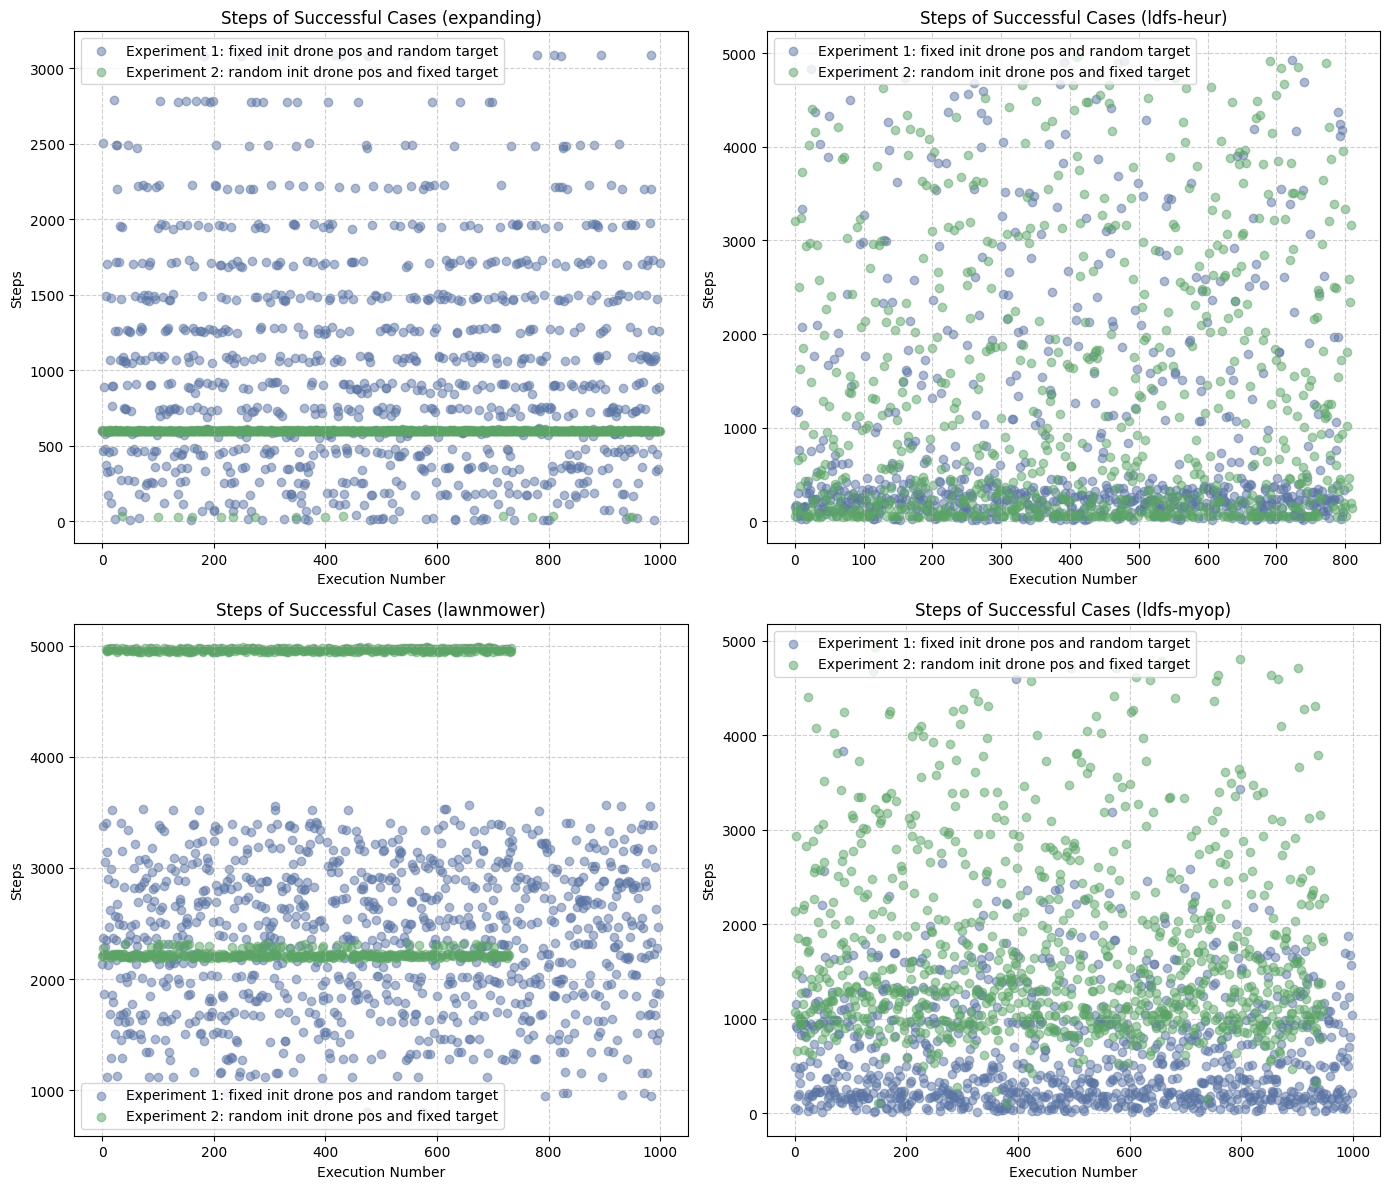

In [40]:
# Definir colores para los experimentos
colors = {'exp1': '#5B75A4', 'exp2': '#5BA466'}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for i, strategy in enumerate(strategies):
    ax = axes[i // 2, i % 2]

    # Filtrar datos por estrategia en cada experimento
    strategy_data_exp1 = successful_df_exp1[successful_df_exp1['Strategy'] == strategy].copy()
    strategy_data_exp2 = successful_df_exp2[successful_df_exp2['Strategy'] == strategy].copy()

    # Agregar índices de ejecución
    strategy_data_exp1.reset_index(drop=True, inplace=True)
    strategy_data_exp2.reset_index(drop=True, inplace=True)

    # Graficar los datos de cada experimento en colores diferentes
    ax.scatter(strategy_data_exp1.index, strategy_data_exp1['Steps'], 
               color=colors['exp1'], alpha=0.5, label='Experiment 1: fixed init drone pos and random target')

    ax.scatter(strategy_data_exp2.index, strategy_data_exp2['Steps'], 
               color=colors['exp2'], alpha=0.5, label='Experiment 2: random init drone pos and fixed target')

    ax.set_title(f'Steps of Successful Cases ({strategy})')
    ax.set_xlabel('Execution Number')
    ax.set_ylabel('Steps')
    ax.grid(True, linestyle="--", alpha=0.6)

    ax.legend()

plt.tight_layout()
plt.show()


# Limpiar entorno

In [ ]:
drive.flush_and_unmount()

Colores: #A45B75, #5BA48A, #655BA4, #75A45B y #5B75A4